# **Idemia Datachallenge (IADATA704): Face Occlusion Prediction**

**Group Name:** Team GPU  
**Group Number:** 21  
**Team Members:** Oscar DE LA CRUZ 

**Project repository:** [https://github.com/odelacruz-fierro/data-challenge-idemia.git](https://github.com/odelacruz-fierro/data-challenge-idemia.git)

---

In [153]:
# --- Standard Library Imports ---
import os

# --- Third-Party Library Imports ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import random

# -----------------------------------------------------------------
# /!\ This notebook MUST BE at the root of the project folder /!\
# -----------------------------------------------------------------

# --- Local Project Modules ---
from src import config



EXPERIMENTS = [folder.name for folder in os.scandir(f"/{config.OUOTPUT_DIR}") if folder.is_dir()]
EXPERIMENTS.sort()

for EXP in EXPERIMENTS:
    print(EXP)
    
# --- Select experiment ---
MODEL_NUM = 4

VAL_PREDICTIONS = f"/{config.OUOTPUT_DIR}/{EXPERIMENTS[MODEL_NUM-1]}/best_validation_predictions.csv"
TRAIN_HISTORY = f"/{config.OUOTPUT_DIR}/{EXPERIMENTS[MODEL_NUM-1]}/training_history.csv"
TEST_PREDICTIONS = f"/{config.OUOTPUT_DIR}/{EXPERIMENTS[MODEL_NUM-1]}/test_predictions.csv"

# --- Check files existence ---
files = [VAL_PREDICTIONS,
         TRAIN_HISTORY,
         TEST_PREDICTIONS]

for file in files:
    if os.path.exists(file):
        print(f"File O.k.! :\t{file}")
    else:
        print(f"File NOT O.k.! : {file}")

MODEL_01_20260606_task_imbalance_effect
MODEL_02_20260607_task_balance_improved
MODEL_03_20260607_using_sampler
MODEL_04_20260607_reduced_gamma_sampler
File O.k.! :	/home/mambo/Documents/data-challenge-idemia/outputs/MODEL_04_20260607_reduced_gamma_sampler/best_validation_predictions.csv
File O.k.! :	/home/mambo/Documents/data-challenge-idemia/outputs/MODEL_04_20260607_reduced_gamma_sampler/training_history.csv
File O.k.! :	/home/mambo/Documents/data-challenge-idemia/outputs/MODEL_04_20260607_reduced_gamma_sampler/test_predictions.csv


## **1. Data overview**

In [154]:
df_train_history = pd.read_csv(TRAIN_HISTORY, delimiter=',')
df_val_pred = pd.read_csv(VAL_PREDICTIONS, delimiter=',')
df_test_pred = pd.read_csv(TEST_PREDICTIONS, delimiter=',')

In [155]:
# --- Train history ---
df_train_history.info()
df_train_history.head()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   epoch              10 non-null     int64  
 1   gamma_gender       10 non-null     float64
 2   idemia_val_score   10 non-null     float64
 3   train_loss_total   10 non-null     float64
 4   train_loss_occ     10 non-null     float64
 5   train_loss_gender  10 non-null     float64
 6   val_loss_total     10 non-null     float64
 7   val_loss_occ       10 non-null     float64
 8   val_loss_gender    10 non-null     float64
dtypes: float64(8), int64(1)
memory usage: 852.0 bytes


,epoch,gamma_gender,idemia_val_score,train_loss_total,train_loss_occ,train_loss_gender,val_loss_total,val_loss_occ,val_loss_gender
0,1,0.015,0.004062,0.003605,0.001784,0.121417,0.002779,0.001341,0.095848
1,2,0.015,0.002010,0.001877,0.000984,0.059527,0.002133,0.001104,0.068549
2,3,0.015,0.001847,0.001592,0.000891,0.046762,0.002065,0.000962,0.073503
3,4,0.015,0.001795,0.001366,0.000784,0.038759,0.001812,0.000847,0.064333
4,5,0.015,0.001902,0.001195,0.000738,0.030476,0.001847,0.000884,0.064211


In [156]:
# --- Validation predictions ---
df_val_pred.info()
df_val_pred.head()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   filename     20000 non-null  str    
 1   pred         20000 non-null  float64
 2   target       20000 non-null  float64
 3   gender       20000 non-null  int64  
 4   gender_pred  20000 non-null  int64  
dtypes: float64(2), int64(2), str(1)
memory usage: 781.4 KB


,filename,pred,target,gender,gender_pred
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.026703,0.024005,1,1
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.028460,0.030028,1,1
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.012224,0.009984,0,0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.215788,0.255016,1,1
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.243374,0.252091,1,1


In [157]:
# --- Test predictions ---
df_test_pred.info()
df_test_pred.head()

<class 'pandas.DataFrame'>
RangeIndex: 29980 entries, 0 to 29979
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   filename       29980 non-null  str    
 1   FaceOcclusion  29980 non-null  float64
 2   gender         29980 non-null  str    
dtypes: float64(1), str(2)
memory usage: 702.8 KB


,filename,FaceOcclusion,gender
0,database3/database3/m.0256vn/81-FaceId-0_align...,0.041885,x
1,database3/database3/m.01dgwg/29-FaceId-0_align...,0.036291,x
2,database3/database3/m.02l0nk/72-FaceId-0_align...,0.015657,x
3,database3/database3/m.026jp3/94-FaceId-1_align...,0.021496,x
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...,0.020664,x


## **2. Train/Validation loss**
### **2.1 Total loss**

gamma_gender = 0.015


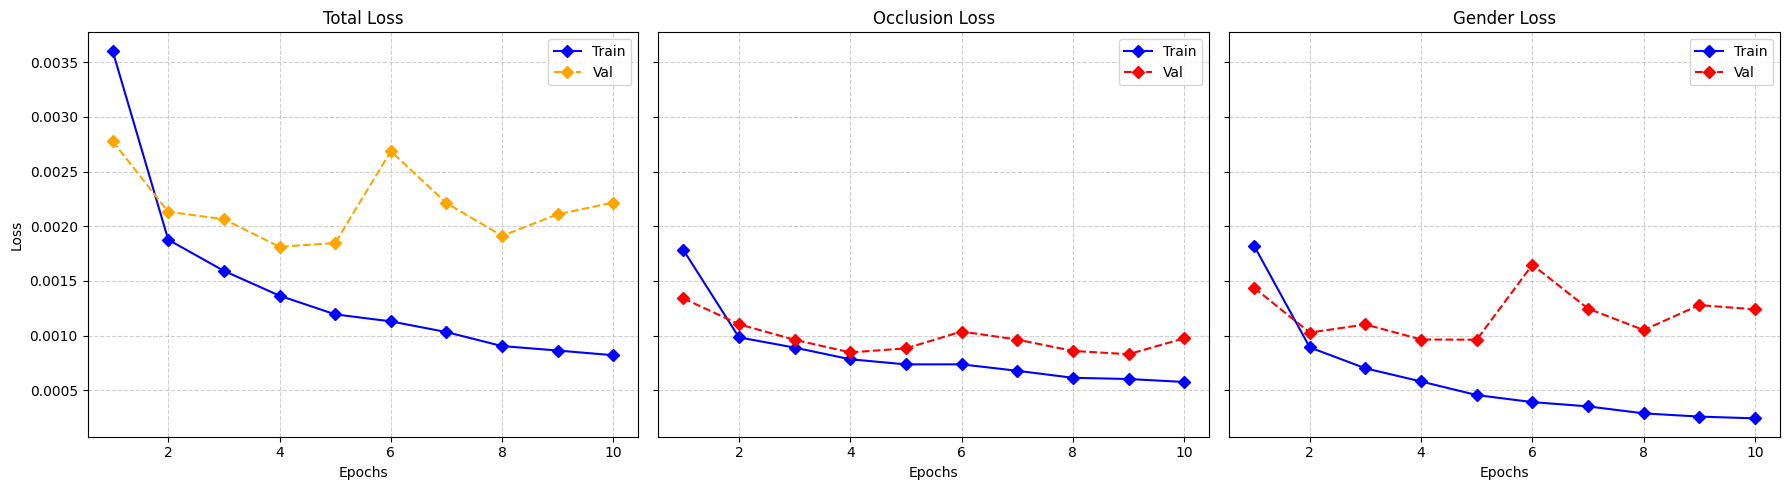

In [158]:
# --- Retrieve data from dataframes ---

epochs =np.arange(1, len(df_train_history)+1)

gamma_gender = df_train_history['gamma_gender'][0]

print(f"gamma_gender = {gamma_gender}")

# Total
train_loss_total = df_train_history['train_loss_total'].to_numpy()
val_loss_total = df_train_history['val_loss_total'].to_numpy()

# Occlusion
train_loss_occ = df_train_history['train_loss_occ'].to_numpy()
val_loss_occ = df_train_history['val_loss_occ'].to_numpy()

# Gender
train_loss_gender = df_train_history['train_loss_gender'].to_numpy()
val_loss_gender = df_train_history['val_loss_gender'].to_numpy()

# --- Subplot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5),sharey=True)


# --- Plot 1: Total Loss ---
axes[0].plot(epochs, train_loss_total, label='Train', color='blue',marker='D')
axes[0].plot(epochs, val_loss_total, label='Val', color='orange',marker='D',linestyle='--')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# --- Plot 2: Occlusion Loss ---
axes[1].plot(epochs, train_loss_occ, label='Train', color='blue',marker='D')
axes[1].plot(epochs, val_loss_occ, label='Val', color='red',marker='D',linestyle='--')
axes[1].set_title('Occlusion Loss')
axes[1].set_xlabel('Epochs')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# --- Plot 3: Gender Loss ---
axes[2].plot(epochs, gamma_gender*train_loss_gender, label='Train', color='blue',marker='D')
#axes[2].plot(epochs, val_loss_gender, label='Val', color='brown')
axes[2].plot(epochs, gamma_gender*val_loss_gender, label='Val', color='red',marker='D',linestyle='--')
axes[2].set_title('Gender Loss')
axes[2].set_xlabel('Epochs')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

plt.tight_layout()
plt.show()

## **3. Idemia score**

best_score = 0.0014366647927253


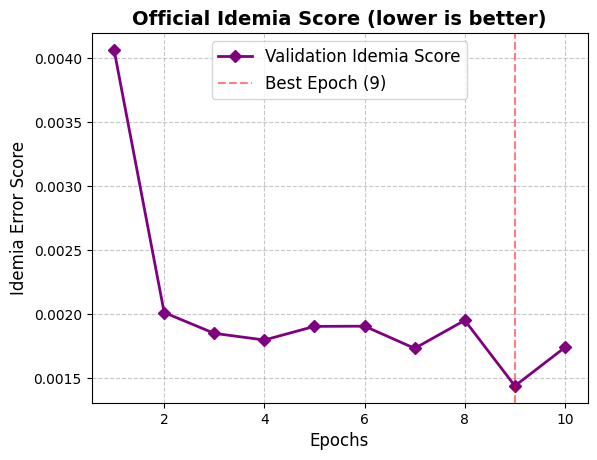

In [159]:
idemia_score = df_train_history['idemia_val_score'].to_numpy()


plt.plot(epochs, idemia_score, label='Validation Idemia Score', color='purple', marker='D', linewidth=2)

# Highlight the best epoch
best_epoch = epochs[np.argmin(idemia_score)]
best_score = np.min(idemia_score)
print(f"best_score = {best_score}")
plt.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best Epoch ({best_epoch})')

# Add labels and grids
plt.title('Official Idemia Score (lower is better)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Idemia Error Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# Show the plot
plt.show()

## **4. Prediction distribution**

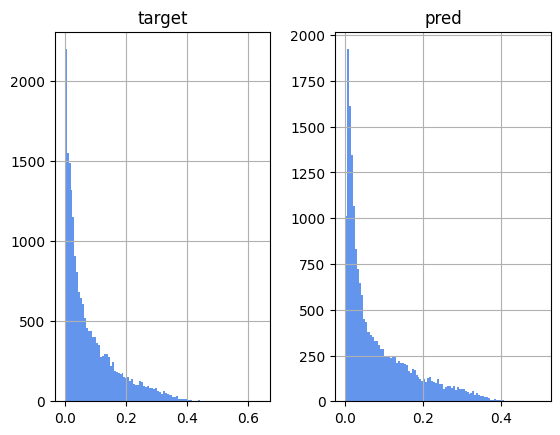

In [160]:
# --- Histogram validation split ---
hist_occlusion = df_val_pred.hist(column = ['target','pred'], bins = 100, color='cornflowerblue')

(0.0, 1.1)

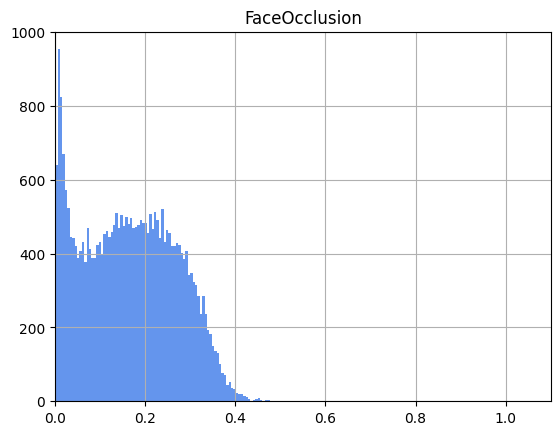

In [166]:
# --- Histogram test split ---
hist_occlusion = df_test_pred.hist(column = ['FaceOcclusion'], bins = 100, color='cornflowerblue')
hist_occlusion[0][0].set_xlim(0, 1.1)